# VRP v2 — Matched-Horizon VRP and Tail-Conditional Entry

**Provenance (2026-08-04):** v2 of the VRP study. `vrp_arma_signal.ipynb` is the rough draft this replaces; its issues are catalogued in `docs/audits/2026-07-07-adversarial-audit-{fable,opus}.md`. Data: `data/spy_vix_1993_2026.csv`, SPY (auto-adjusted close) + ^VIX from yfinance, snapshotted 2026-08-03, 8,432 trading days (Feb 1993 – Jul 2026).

**What this version fixes relative to v1:**
- **Horizon match (was V-C2):** both legs of every quantity now refer to the same forward 21-trading-day (≈30 calendar-day) window that VIX prices.
- **Real payoff (was V-C3):** the traded quantity is a synthetic 30-day variance-swap seller's payoff, VIX²ₜ − realized variance over the next 21 trading days — an approximation of an actual instrument's P&L, not a sum of spread levels. A strike-haircut sensitivity stands in for costs.
- **Causal signals only:** every conditioning variable is known at the close of day *t*; GARCH is refit annually on an expanding window with a closed-form multi-step forecast (no ARMA — v1's corrected result showed ARMA ≈ persistence, DM p=0.30).
- **Fixed-quantile CVaR with n reported (was V-M1/V-C1 hygiene),** thresholds from train quantiles only, and a block-bootstrap significance check.

**Research question:** can conditioning information available at entry reduce the left tail of short-variance payoffs, and at what cost in premium?

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

warnings.filterwarnings('ignore')

H = 21                       # trading-day horizon matching VIX's 30 calendar days
TRAIN_END = '2010-01-01'     # train 1993-2009 (incl. 1997/1998/2008 tails), OOS 2010-2026
DATA = 'data/spy_vix_1993_2026.csv'

## Definitions

- **Payoff (per unit variance notional), decided at close of day t:** `payoff_t = IV²_t − RV²_{t+1..t+H}` where `IV² = (VIX/100)²` is the strike of a synthetic 30-day variance swap and `RV²` is annualized realized variance of SPY log returns over the next 21 trading days. Positive = the seller keeps premium.
- **Ex-ante VRP (causal signal):** `evrp_t = IV²_t − E_t[RV²_{t+1..t+H}]`, with the expectation from a GARCH(1,1)-t multi-step forecast using only data ≤ t.
- **State variables (causal):** `gvol_fc` = GARCH 21-day vol forecast; `rv_mom` = 5-day / 63-day realized vol ratio (vol acceleration).

**Known approximations:** VIX² is not exactly a tradeable strike (replication gap, jump premium, bid-ask); 30 calendar ≈ 21 trading days; daily entries overlap heavily (a non-overlapping check follows); costs enter only via the strike-haircut sensitivity. Results are a *payoff-proxy* study, one step short of a production backtest with listed instruments.

In [2]:
df = pd.read_csv(DATA, index_col='Date', parse_dates=True)
df['r'] = np.log(df['SPY'] / df['SPY'].shift(1))
df = df.dropna()

sq = df['r'] ** 2
# forward realized variance over t+1..t+H, annualized (decimal²) — PAYOFF LEG ONLY, never a signal
df['fwd_rv2'] = sq.shift(-1).rolling(H).sum().shift(-(H - 1)) * (252 / H)
df['iv2'] = (df['^VIX'] / 100) ** 2
df['payoff'] = df['iv2'] - df['fwd_rv2']

# causal state variables (known at close t)
df['rv5'] = np.sqrt(sq.rolling(5).sum() * 252 / 5)
df['rv63'] = np.sqrt(sq.rolling(63).sum() * 252 / 63)
df['rv_mom'] = df['rv5'] / df['rv63']

print(df.shape, df.index.min().date(), '→', df.index.max().date())

(8431, 9) 1993-02-02 → 2026-07-31


In [3]:
# GARCH(1,1)-t, zero mean, fit on 100×log-returns; expanding annual refits.
# E_t[σ²_{t+h}] = σ̄² + (α+β)^{h-1} (σ²_{t+1|t} − σ̄²)  →  average over h=1..H, annualize.
r100 = df['r'] * 100
r2 = (r100 ** 2).values

def filtered_forecast(om, al, be):
    """Daily-filtered E_t[avg σ² over t+1..t+H] for the whole series, annualized decimal²."""
    pers, uncond = al + be, om / (1 - al - be)
    cv = np.empty(len(df)); cv[0] = uncond
    for i in range(1, len(df)):
        cv[i] = om + al * r2[i - 1] + be * cv[i - 1]
    cv_next = om + al * r2 + be * cv                       # σ²_{t+1|t}, daily %²
    w = np.mean([pers ** (h - 1) for h in range(1, H + 1)])
    return pd.Series((uncond + w * (cv_next - uncond)) * 252 / 1e4, index=df.index)

refit_dates = [pd.Timestamp(TRAIN_END)] + [pd.Timestamp(f'{y}-01-01') for y in range(2011, 2027)]
egarch_fc = pd.Series(index=df.index, dtype=float)
params_log = []
for j, rd in enumerate(refit_dates):
    res = arch_model(r100[r100.index < rd], vol='GARCH', p=1, q=1, mean='Zero', dist='t').fit(disp='off')
    om, al, be = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
    params_log.append((rd.year, om, al, be, al + be))
    fc = filtered_forecast(om, al, be)
    hi = refit_dates[j + 1] if j + 1 < len(refit_dates) else pd.Timestamp('2100-01-01')
    mask = (df.index >= rd) & (df.index < hi)
    egarch_fc.loc[mask] = fc[mask]
    if j == 0:
        train_fc = fc[fc.index < pd.Timestamp(TRAIN_END)]   # first-refit params, in-sample on train

df['egarch_fc'] = egarch_fc
df['evrp'] = df['iv2'] - df['egarch_fc']
df['gvol_fc'] = np.sqrt(df['egarch_fc'])

pl = pd.DataFrame(params_log, columns=['refit_year', 'omega', 'alpha', 'beta', 'persistence'])
print(pl.iloc[[0, -1]].to_string(index=False))

 refit_year    omega    alpha     beta  persistence
       2010 0.005624 0.066804 0.931409     0.998213
       2026 0.013535 0.108617 0.886039     0.994656


## Split and thresholds

Thresholds come from **train quantiles only** (1993–2009). The train-period `evrp` uses the first refit's parameters in-sample — mild within-train hindsight that never touches OOS (same caveat class as v1 audit V-M2, acknowledged).

In [4]:
oos = df[df.index >= TRAIN_END].dropna(subset=['payoff', 'evrp', 'rv_mom']).copy()
train = df[df.index < TRAIN_END].dropna(subset=['rv_mom']).copy()
train['gvol_fc_t'] = np.sqrt(train_fc.reindex(train.index))
train['evrp_t'] = train['iv2'] - train_fc.reindex(train.index)

q_vol_hi  = train['gvol_fc_t'].quantile(0.90)   # 'vol forecast is high'
q_evrp_lo = train['evrp_t'].quantile(0.20)      # 'premium is thin'
q_mom_hi  = train['rv_mom'].quantile(0.90)      # 'vol is accelerating'

print(f'train: {train.index.min().date()} → {train.index.max().date()} (n={len(train)})')
print(f'OOS:   {oos.index.min().date()} → {oos.index.max().date()} (n={len(oos)})')
print(f'thresholds: gvol_fc q90={q_vol_hi:.3f}  evrp q20={q_evrp_lo:.5f}  rv_mom q90={q_mom_hi:.3f}')

train: 1993-05-03 → 2009-12-31 (n=4200)
OOS:   2010-01-04 → 2026-07-01 (n=4148)
thresholds: gvol_fc q90=0.278  evrp q20=0.00173  rv_mom q90=1.429


In [5]:
sigs = {
    'always-in':      pd.Series(True, index=oos.index),
    'v1-rule-evrp>0': oos['evrp'] > 0,                    # v1's naive rule, horizon-matched
    'skip-highvol':   oos['gvol_fc'] <= q_vol_hi,
    'skip-thin-evrp': oos['evrp'] >= q_evrp_lo,
    'skip-rv-mom':    oos['rv_mom'] <= q_mom_hi,
    'combined':       (oos['gvol_fc'] <= q_vol_hi) & (oos['evrp'] >= q_evrp_lo) & (oos['rv_mom'] <= q_mom_hi),
}

def stats(pay):
    q05 = pay.quantile(0.05)
    return {'n': len(pay), 'mean': pay.mean(), 'hit': (pay > 0).mean(),
            'CVaR5': pay[pay <= q05].mean(), 'worst': pay.min()}

base = stats(oos['payoff']); base_total = oos['payoff'].sum()
rows = []
for name, s in sigs.items():
    st = stats(oos.loc[s, 'payoff'])
    st['premium_kept'] = oos.loc[s, 'payoff'].sum() / base_total
    st['CVaR_cut'] = 1 - st['CVaR5'] / base['CVaR5']
    rows.append(pd.Series(st, name=name))
table = pd.DataFrame(rows)
disp = table.copy()
for c, fmt in [('mean', '{:.4f}'), ('hit', '{:.1%}'), ('CVaR5', '{:.4f}'), ('worst', '{:.4f}'),
               ('premium_kept', '{:.1%}'), ('CVaR_cut', '{:.1%}')]:
    disp[c] = disp[c].map(fmt.format)
disp

,n,mean,hit,CVaR5,worst,premium_kept,CVaR_cut
always-in,4148.0,0.0092,84.5%,-0.1307,-0.7503,100.0%,0.0%
v1-rule-evrp>0,3342.0,0.0093,84.6%,-0.1185,-0.7503,81.4%,9.3%
skip-highvol,3885.0,0.0081,84.2%,-0.1060,-0.7503,83.2%,18.8%
skip-thin-evrp,3039.0,0.0100,84.2%,-0.1150,-0.7503,80.1%,12.0%
skip-rv-mom,3637.0,0.0101,84.9%,-0.0879,-0.6907,96.3%,32.7%
combined,2639.0,0.0096,84.1%,-0.0830,-0.6907,66.4%,36.4%


In [6]:
worst10 = oos['payoff'].nsmallest(10)
flags = pd.DataFrame({name: sigs[name].loc[worst10.index] for name in sigs if name != 'always-in'})
flags.insert(0, 'payoff', worst10)
print('worst 10 always-in entry dates — True = filter was still IN (ate the loss):')
print(flags.to_string())

worst 10 always-in entry dates — True = filter was still IN (ate the loss):
              payoff  v1-rule-evrp>0  skip-highvol  skip-thin-evrp  skip-rv-mom  combined
Date                                                                                     
2020-02-26 -0.750341            True          True            True        False     False
2020-02-24 -0.733877            True          True            True        False     False
2020-02-25 -0.710253            True          True            True        False     False
2020-03-04 -0.703997           False         False           False        False     False
2020-03-02 -0.693423           False         False           False        False     False
2020-02-21 -0.690738            True          True            True         True      True
2020-02-20 -0.688935            True          True            True         True      True
2020-03-03 -0.684860            True         False            True        False     False
2020-02-19 -0.669386    

In [7]:
# non-overlapping honesty check: one entry every 21st day (independent payoff windows)
no = oos.iloc[::H]
print('non-overlapping entries (every 21st day):')
for name, s in sigs.items():
    st = stats(no.loc[s.loc[no.index], 'payoff'])
    print(f"{name:16s} n={st['n']:4d} mean={st['mean']:8.4f} hit={st['hit']:.1%} "
          f"CVaR5={st['CVaR5']:8.4f} worst={st['worst']:8.4f}")

non-overlapping entries (every 21st day):
always-in        n= 198 mean=  0.0083 hit=83.8% CVaR5= -0.1369 worst= -0.5220
v1-rule-evrp>0   n= 157 mean=  0.0115 hit=85.4% CVaR5= -0.0794 worst= -0.2088
skip-highvol     n= 185 mean=  0.0082 hit=83.2% CVaR5= -0.0877 worst= -0.2088
skip-thin-evrp   n= 142 mean=  0.0135 hit=85.9% CVaR5= -0.0553 worst= -0.1646
skip-rv-mom      n= 171 mean=  0.0114 hit=84.8% CVaR5= -0.0519 worst= -0.1646
combined         n= 124 mean=  0.0104 hit=84.7% CVaR5= -0.0557 worst= -0.1646


In [8]:
# circular block bootstrap (block = 21d) on CVaR5 cut and mean-payoff difference vs always-in
rng = np.random.default_rng(42)
B, BL = 2000, 21
pay_all = oos['payoff'].values
n = len(pay_all)

def resample_idx():
    starts = rng.integers(0, n, size=n // BL + 1)
    return ((starts[:, None] + np.arange(BL)[None, :]).ravel() % n)[:n]

for name in ['skip-rv-mom', 'combined']:
    s = sigs[name].values
    cuts, mdiffs = np.empty(B), np.empty(B)
    for b in range(B):
        idx = resample_idx()
        p, m = pay_all[idx], s[idx]
        qa = np.quantile(p, 0.05); ca = p[p <= qa].mean()
        pf = p[m]
        qf = np.quantile(pf, 0.05); cf = pf[pf <= qf].mean()
        cuts[b] = 1 - cf / ca
        mdiffs[b] = pf.mean() - p.mean()
    print(f'{name:14s} CVaR5-cut CI90=[{np.quantile(cuts, .05):.1%}, {np.quantile(cuts, .95):.1%}] '
          f'P(cut>0)={np.mean(cuts > 0):.1%}  mean-diff CI90=[{np.quantile(mdiffs, .05):+.4f}, {np.quantile(mdiffs, .95):+.4f}]')

skip-rv-mom    CVaR5-cut CI90=[2.7%, 53.5%] P(cut>0)=98.1%  mean-diff CI90=[-0.0013, +0.0044]


combined       CVaR5-cut CI90=[-0.6%, 56.5%] P(cut>0)=94.4%  mean-diff CI90=[-0.0025, +0.0040]


In [9]:
# cost sensitivity: seller receives a strike 0.5 vol-points below VIX
pay_hc = ((oos['^VIX'] - 0.5) / 100) ** 2 - oos['fwd_rv2']
print('with 0.5 vol-pt strike haircut:')
for name, s in sigs.items():
    st = stats(pay_hc[s])
    print(f"{name:16s} mean={st['mean']:8.4f} hit={st['hit']:.1%} CVaR5={st['CVaR5']:8.4f}")

with 0.5 vol-pt strike haircut:
always-in        mean=  0.0073 hit=82.9% CVaR5= -0.1326
v1-rule-evrp>0   mean=  0.0075 hit=82.9% CVaR5= -0.1203
skip-highvol     mean=  0.0064 hit=82.6% CVaR5= -0.1078
skip-thin-evrp   mean=  0.0082 hit=82.6% CVaR5= -0.1168
skip-rv-mom      mean=  0.0083 hit=83.2% CVaR5= -0.0896
combined         mean=  0.0078 hit=82.3% CVaR5= -0.0847


In [10]:
# Headline pre-committed rule, gross and net of the strike haircut.
# The rule reported in docs/specs/vrp-tail-v2.md and the README is the 10d/126d RV ratio
# selected on train, NOT the 5d/63d `rv_mom` used in the sweep above. Built here so the
# notebook computes its own headline; the haircut cell above prints mean/hit/CVaR5 only,
# so premium_kept and CVaR_cut were never shown net of costs.
rv10 = np.sqrt(sq.rolling(10).sum() * 252 / 10)
rv126 = np.sqrt(sq.rolling(126).sum() * 252 / 126)
mom_10_126 = rv10 / rv126
thr_10_126 = mom_10_126[mom_10_126.index < TRAIN_END].quantile(0.90)   # train only
sig_hl = mom_10_126.reindex(oos.index) <= thr_10_126

print(f'headline rule: rv10/rv126 <= train q90 = {thr_10_126:.4f}')
print(f'skipped {(~sig_hl).sum()} of {len(oos)} entries; in market {sig_hl.mean():.1%}')

FMT = {'n': '{:.0f}', 'mean': '{:.4f}', 'std': '{:.4f}', 'hit': '{:.1%}', 'CVaR5': '{:.4f}',
       'worst': '{:.4f}', 'premium_kept': '{:.2%}', 'CVaR_cut': '{:.2%}'}


def headline_table(pay):
    """always-in vs filtered, with premium_kept and CVaR_cut, for one payoff series."""
    b, f = pay, pay[sig_hl]
    cvar = lambda x: x[x <= x.quantile(0.05)].mean()
    cols = {
        'always-in': [len(b), b.mean(), b.std(), (b > 0).mean(), cvar(b), b.min(), 1.0, 0.0],
        'filtered':  [len(f), f.mean(), f.std(), (f > 0).mean(), cvar(f), f.min(),
                      f.sum() / b.sum(), 1 - cvar(f) / cvar(b)],
    }
    return pd.DataFrame({k: [FMT[r].format(v) for r, v in zip(FMT, vals)]
                         for k, vals in cols.items()}, index=list(FMT))


print('\nGROSS')
print(headline_table(oos['payoff']).to_string())
print('\nNET — 0.5 vol-pt strike haircut')
print(headline_table(pay_hc).to_string())

headline rule: rv10/rv126 <= train q90 = 1.4266
skipped 462 of 4148 entries; in market 88.9%

GROSS
             always-in filtered
n                 4148     3686
mean            0.0092   0.0100
std             0.0551   0.0390
hit              84.5%    85.3%
CVaR5          -0.1307  -0.0876
worst          -0.7503  -0.6907
premium_kept   100.00%   96.71%
CVaR_cut         0.00%   32.94%

NET — 0.5 vol-pt strike haircut
             always-in filtered
n                 4148     3686
mean            0.0073   0.0082
std             0.0550   0.0388
hit              82.9%    83.6%
CVaR5          -0.1326  -0.0893
worst          -0.7531  -0.6924
premium_kept   100.00%   99.65%
CVaR_cut         0.00%   32.65%


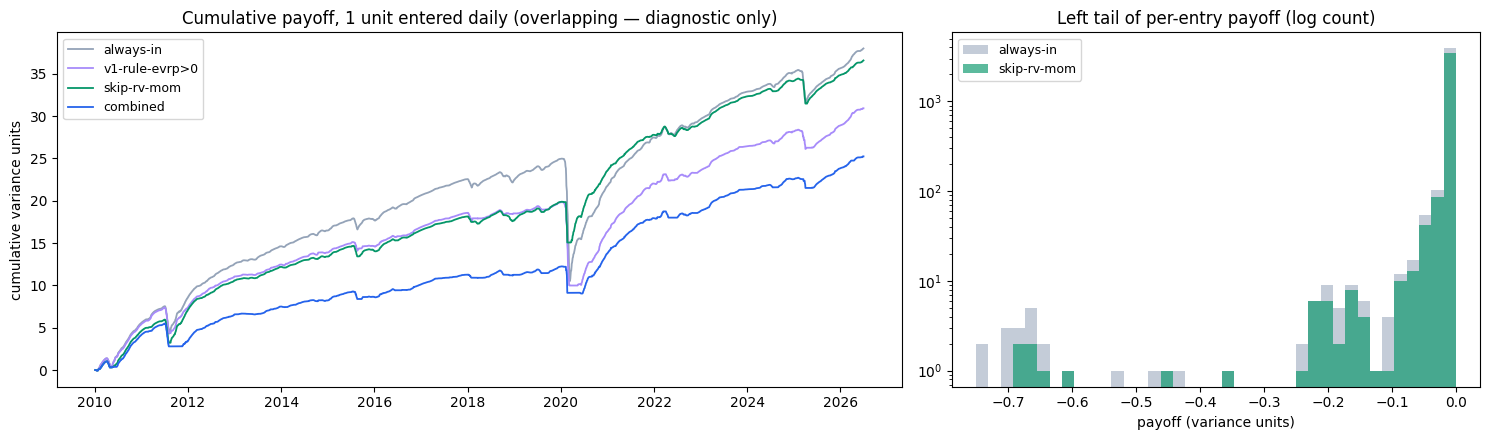

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[1.6, 1])

for name, color in [('always-in', '#94a3b8'), ('v1-rule-evrp>0', '#a78bfa'),
                    ('skip-rv-mom', '#059669'), ('combined', '#2563eb')]:
    cum = oos['payoff'].where(sigs[name], 0.0).cumsum()
    ax1.plot(cum.index, cum.values, lw=1.3, color=color, label=name)
ax1.set_title('Cumulative payoff, 1 unit entered daily (overlapping — diagnostic only)')
ax1.set_ylabel('cumulative variance units')
ax1.legend(fontsize=9)

bins = np.linspace(oos['payoff'].min(), 0, 40)
ax2.hist(oos.loc[sigs['always-in'], 'payoff'].clip(upper=0), bins=bins, alpha=0.55,
         color='#94a3b8', label='always-in')
ax2.hist(oos.loc[sigs['skip-rv-mom'], 'payoff'].clip(upper=0), bins=bins, alpha=0.65,
         color='#059669', label='skip-rv-mom')
ax2.set_yscale('log')
ax2.set_title('Left tail of per-entry payoff (log count)')
ax2.set_xlabel('payoff (variance units)')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Findings (2026-08-04, single OOS pass 2010-2026, all numbers from cells above)

**The matched-horizon premium exists.** Selling the synthetic 30-day variance swap daily earned a mean +0.0092 variance units per entry with 84.5% of entries positive over 4,148 OOS days — with the horizon mismatch fixed, on a real payoff proxy, and surviving a 0.5 vol-point strike haircut (mean +0.0073). This replaces v1's contaminated "82% positive" level claim.

**Entry timing can cut the tail without giving up the premium.** The best single filter is realized-vol momentum (stand aside when 5d/63d RV ratio > train q90):
- keeps **96.3%** of total premium while cutting CVaR-5% by **32.7%** (−0.1307 → −0.0879), and slightly raises mean per-entry payoff (+0.0092 → +0.0101);
- block-bootstrap (21d blocks): P(CVaR cut > 0) = **98.1%**, CI90 for the cut = [2.7%, 53.5%] — the direction is robust, the magnitude is not pinned down (tail inference on ~10 vol episodes);
- the mean-payoff improvement is **not** significant (CI90 spans zero) — the defensible claim is tail reduction at ~zero premium cost, not alpha;
- consistent on non-overlapping entries (CVaR −0.1369 → −0.0519).

**v1's approach is answered, not just replaced.** The v1-style rule (in only when ex-ante VRP > 0), now properly horizon-matched, gives up 18.6% of premium for only a 9.3% CVaR cut — dominated by the momentum filter on both axes. Forecasting the *premium* is the weak lever; detecting *vol acceleration* is the strong one.

**The limit of timing.** The filters exited before the worst realized entries (late Feb 2020) but were still in on Feb 18-21, 2020 — jump onsets precede any trailing-window signal. This is tail *reduction*, not tail *elimination*; the residual worst case remains ≈ −0.67.

**Caveats.** One OOS pass with thresholds chosen once from train quantiles (not swept, but also not validated on a second holdout); VIX² is a strike proxy, not an executed instrument (no roll, margin, or liquidity modeling); single GARCH(1,1)-t spec; daily entries overlap (mitigated by the non-overlapping check and block bootstrap).